In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mstats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
sns.set_palette('muted')
print('Libraries loaded OK')

Libraries loaded OK


 Load & first look

In [2]:
DATA_PATH = r'C:\Om\Codes\DM new\data\raw\CC_GENERAL.csv'   # update to your actual path
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(df.dtypes)
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (8950, 18)
CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


Summary statistics

In [3]:
df.describe().round(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8949.00,8950.00,8637.00,8950.00,8950.00
mean,1564.47,0.88,1003.20,592.44,411.07,978.87,0.49,0.20,0.36,0.14,3.25,14.71,4494.45,1733.14,864.21,0.15,11.52
std,2081.53,0.24,2136.63,1659.89,904.34,2097.16,0.40,0.30,0.40,0.20,6.82,24.86,3638.82,2895.06,2372.45,0.29,1.34
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,50.00,0.00,0.02,0.00,6.00
25%,128.28,0.89,39.64,0.00,0.00,0.00,0.08,0.00,0.00,0.00,0.00,1.00,1600.00,383.28,169.12,0.00,12.00
50%,873.39,1.00,361.28,38.00,89.00,0.00,0.50,0.08,0.17,0.00,0.00,7.00,3000.00,856.90,312.34,0.00,12.00
75%,2054.14,1.00,1110.13,577.40,468.64,1113.82,0.92,0.30,0.75,0.22,4.00,17.00,6500.00,1901.13,825.49,0.14,12.00
max,19043.14,1.00,49039.57,40761.25,22500.00,47137.21,1.00,1.00,1.00,1.50,123.00,358.00,30000.00,50721.48,76406.21,1.00,12.00


Impute missing values

In [4]:
mp_median = df['MINIMUM_PAYMENTS'].median()
df['MINIMUM_PAYMENTS'].fillna(mp_median, inplace=True)
print(f'MINIMUM_PAYMENTS median: {mp_median:.2f}')

cl_median = df['CREDIT_LIMIT'].median()
df['CREDIT_LIMIT'].fillna(cl_median, inplace=True)
print(f'CREDIT_LIMIT median: {cl_median:.2f}')

assert df.isnull().sum().sum() == 0, 'Still have missing values!'
print('All missing values resolved.')

MINIMUM_PAYMENTS median: 312.34
CREDIT_LIMIT median: 3000.00
All missing values resolved.


C:\Users\omtil\AppData\Local\Temp\ipykernel_19132\2428212253.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MINIMUM_PAYMENTS'].fillna(mp_median, inplace=True)
C:\Users\omtil\AppData\Local\Temp\ipykernel_19132\2428212253.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

Drop CUST_ID

In [5]:
df.drop(columns=['CUST_ID'], inplace=True)
print(f'Features remaining: {df.shape[1]}')   # should be 17
print(df.columns.tolist())

Features remaining: 17
['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


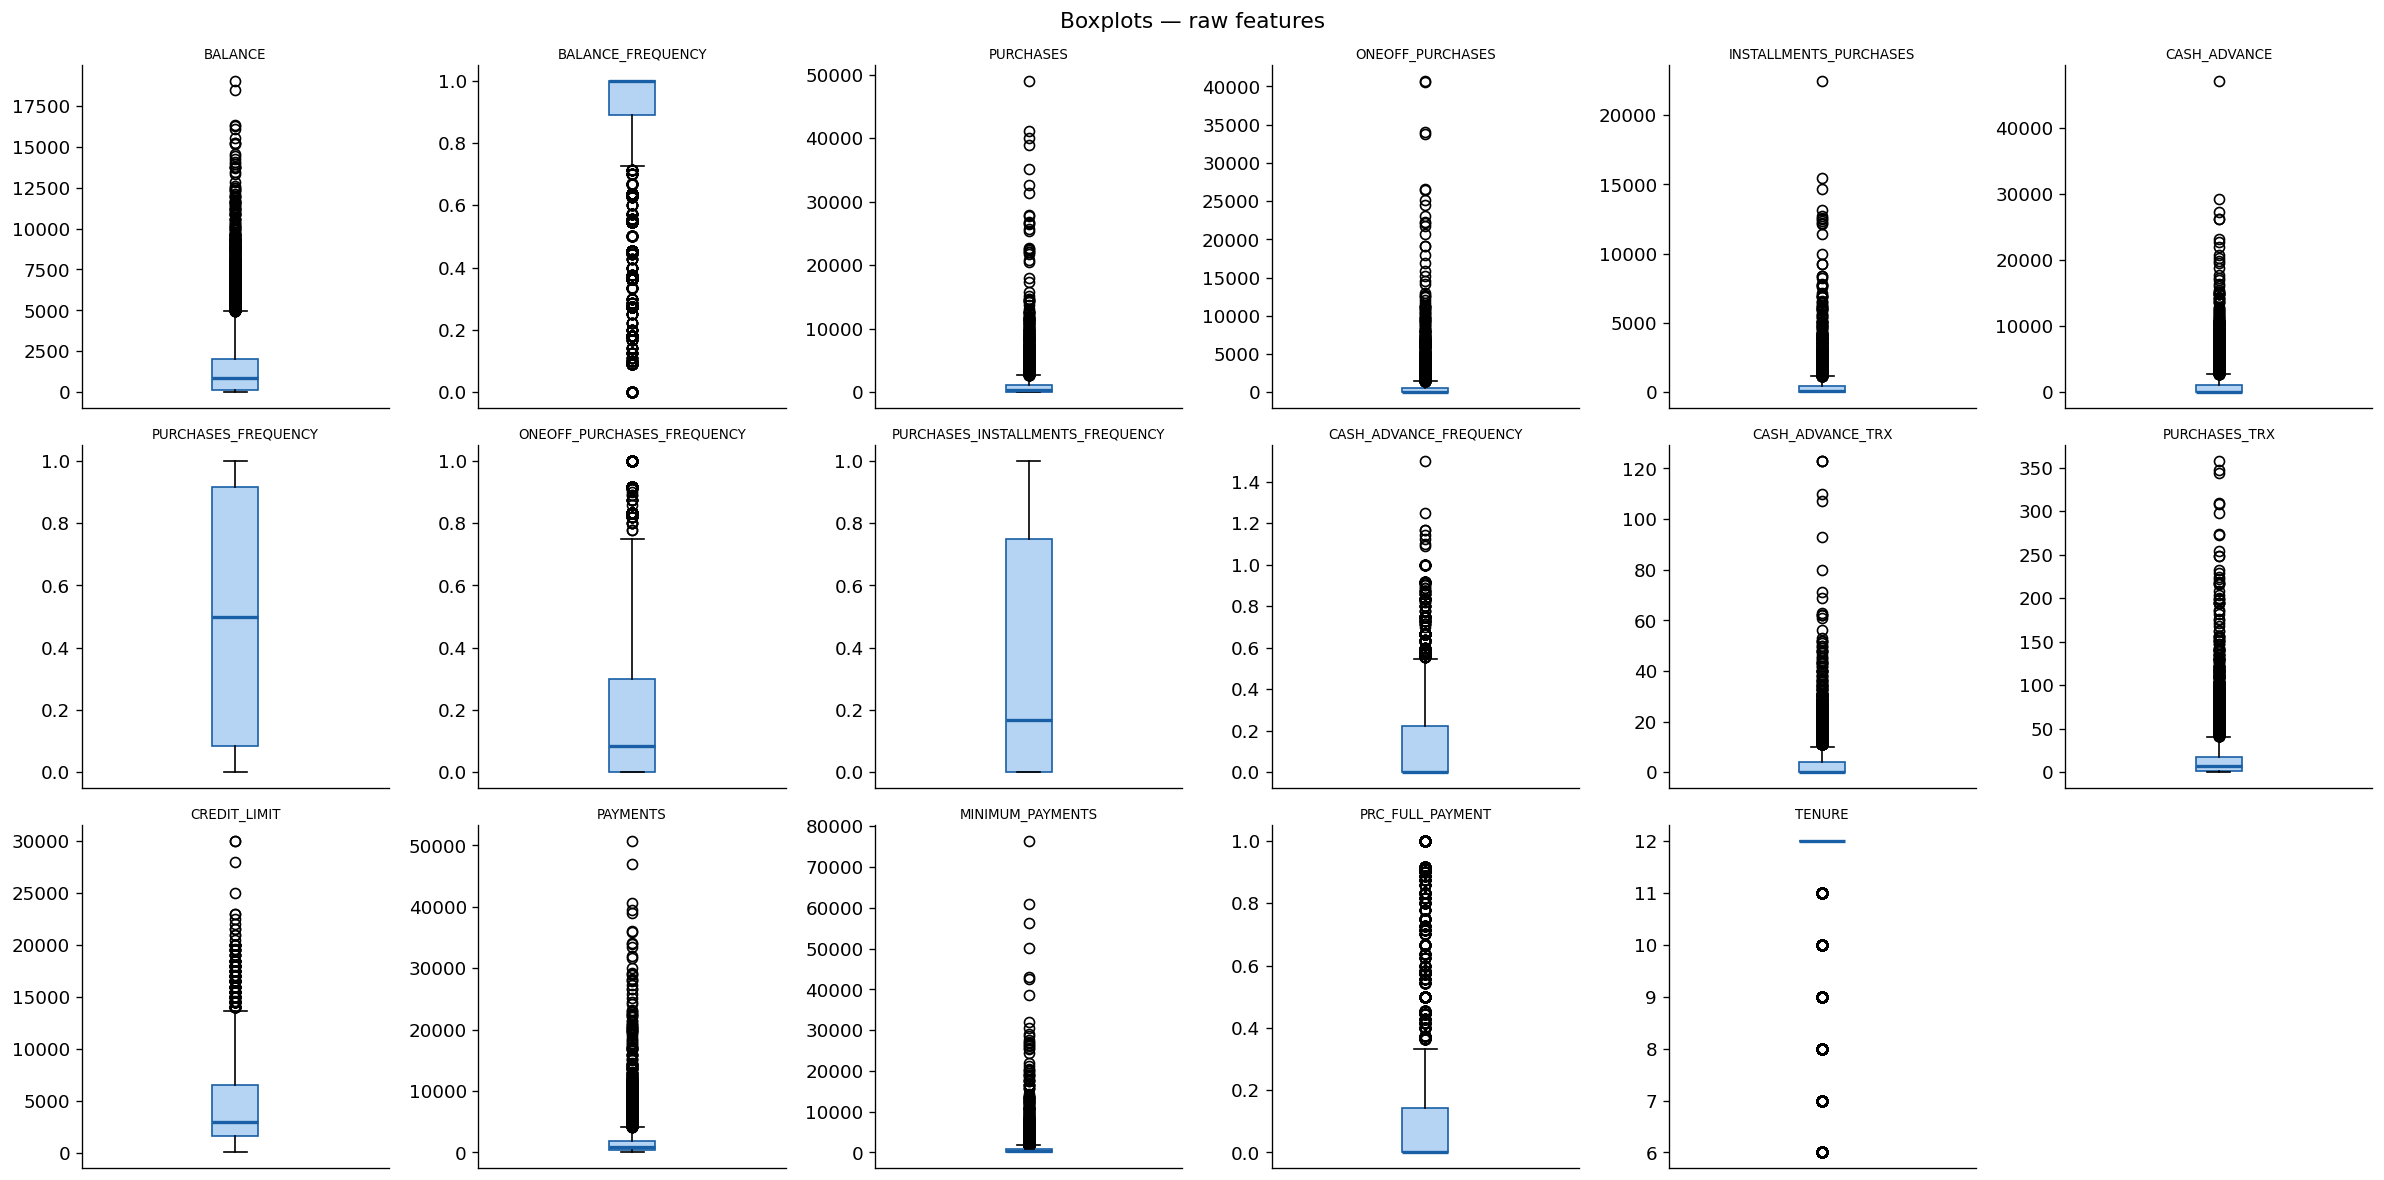

In [6]:
fig, axes = plt.subplots(3, 6, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
                    medianprops=dict(color='#185FA5', linewidth=2))
    axes[i].set_title(col, fontsize=8, pad=4)
    axes[i].tick_params(axis='x', bottom=False, labelbottom=False)

for j in range(len(df.columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — raw features', fontsize=13)
plt.tight_layout()
plt.savefig('fig1_boxplots_raw.png', bbox_inches='tight')
plt.show()

Winsorize (cap outliers)

In [8]:
df_clean = df.copy()

for col in df_clean.columns:
    df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.01, 0.01])

print('Before vs after on PURCHASES:')
print(f'  Max before: {df["PURCHASES"].max():.0f}')
print(f'  Max after:  {df_clean["PURCHASES"].max():.0f}')

Before vs after on PURCHASES:
  Max before: 49040
  Max after:  9008


Log-transform skewed columns

In [9]:
LOG_COLS = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
    'MINIMUM_PAYMENTS', 'CREDIT_LIMIT',
    'PURCHASES_TRX', 'CASH_ADVANCE_TRX'
]

df_log = df_clean.copy()
for col in LOG_COLS:
    df_log[col] = np.log1p(df_log[col])

skew_before = df_clean[LOG_COLS].skew().round(2)
skew_after  = df_log[LOG_COLS].skew().round(2)
print(pd.DataFrame({'Before': skew_before, 'After': skew_after}))

                        Before  After
BALANCE                   1.93  -0.86
PURCHASES                 3.00  -0.78
ONEOFF_PURCHASES          3.35   0.18
INSTALLMENTS_PURCHASES    2.87  -0.03
CASH_ADVANCE              2.73   0.26
MINIMUM_PAYMENTS          4.13   0.36
CREDIT_LIMIT              1.33  -0.06
PURCHASES_TRX             2.69   0.00
CASH_ADVANCE_TRX          2.61   0.88


StandardScaler

In [10]:
scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(df_log)
X_scaled = pd.DataFrame(X_scaled_arr, columns=df_log.columns)

print(f'Shape: {X_scaled.shape}')
print('Mean (should be ~0):')
print(X_scaled.mean().round(4))
print('Std (should be ~1):')
print(X_scaled.std().round(4))

Shape: (8950, 17)
Mean (should be ~0):
BALANCE                             0.0
BALANCE_FREQUENCY                  -0.0
PURCHASES                          -0.0
ONEOFF_PURCHASES                   -0.0
INSTALLMENTS_PURCHASES             -0.0
CASH_ADVANCE                       -0.0
PURCHASES_FREQUENCY                 0.0
ONEOFF_PURCHASES_FREQUENCY          0.0
PURCHASES_INSTALLMENTS_FREQUENCY    0.0
CASH_ADVANCE_FREQUENCY             -0.0
CASH_ADVANCE_TRX                    0.0
PURCHASES_TRX                      -0.0
CREDIT_LIMIT                       -0.0
PAYMENTS                           -0.0
MINIMUM_PAYMENTS                   -0.0
PRC_FULL_PAYMENT                   -0.0
TENURE                              0.0
dtype: float64
Std (should be ~1):
BALANCE                             1.0001
BALANCE_FREQUENCY                   1.0001
PURCHASES                           1.0001
ONEOFF_PURCHASES                    1.0001
INSTALLMENTS_PURCHASES              1.0001
CASH_ADVANCE                   

Correlation heatmap

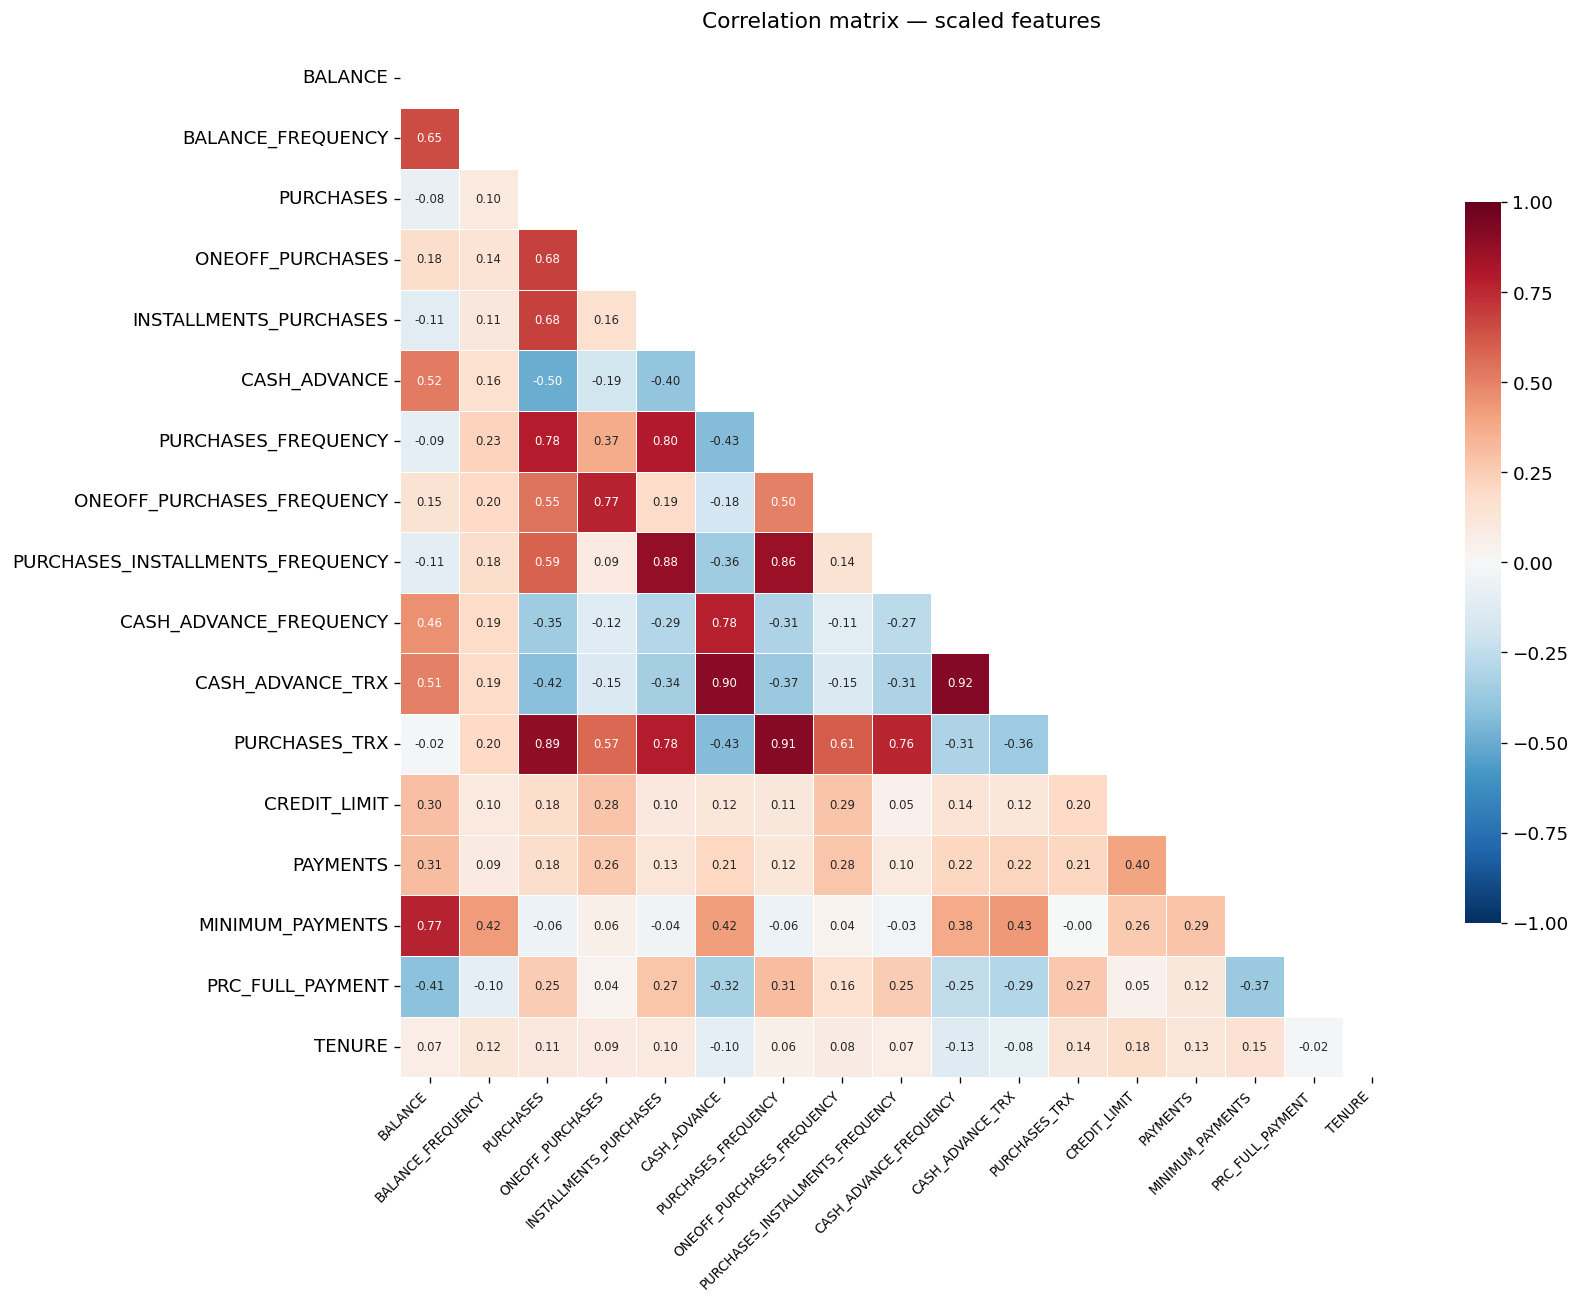

Highly correlated pairs (|r| > 0.7):
  PURCHASES_FREQUENCY <-> PURCHASES: 0.78
  PURCHASES_FREQUENCY <-> INSTALLMENTS_PURCHASES: 0.80
  ONEOFF_PURCHASES_FREQUENCY <-> ONEOFF_PURCHASES: 0.77
  PURCHASES_INSTALLMENTS_FREQUENCY <-> INSTALLMENTS_PURCHASES: 0.88
  PURCHASES_INSTALLMENTS_FREQUENCY <-> PURCHASES_FREQUENCY: 0.86
  CASH_ADVANCE_FREQUENCY <-> CASH_ADVANCE: 0.78
  CASH_ADVANCE_TRX <-> CASH_ADVANCE: 0.90
  CASH_ADVANCE_TRX <-> CASH_ADVANCE_FREQUENCY: 0.92
  PURCHASES_TRX <-> PURCHASES: 0.89
  PURCHASES_TRX <-> INSTALLMENTS_PURCHASES: 0.78
  PURCHASES_TRX <-> PURCHASES_FREQUENCY: 0.91
  PURCHASES_TRX <-> PURCHASES_INSTALLMENTS_FREQUENCY: 0.76
  MINIMUM_PAYMENTS <-> BALANCE: 0.77


In [11]:
corr = X_scaled.corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, annot_kws={'size': 7},
    cbar_kws={'shrink': 0.7}
)
plt.title('Correlation matrix — scaled features', fontsize=13, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('fig2_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Highly correlated pairs (|r| > 0.7):')
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f'  {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.2f}')

Distribution plots (before vs after)

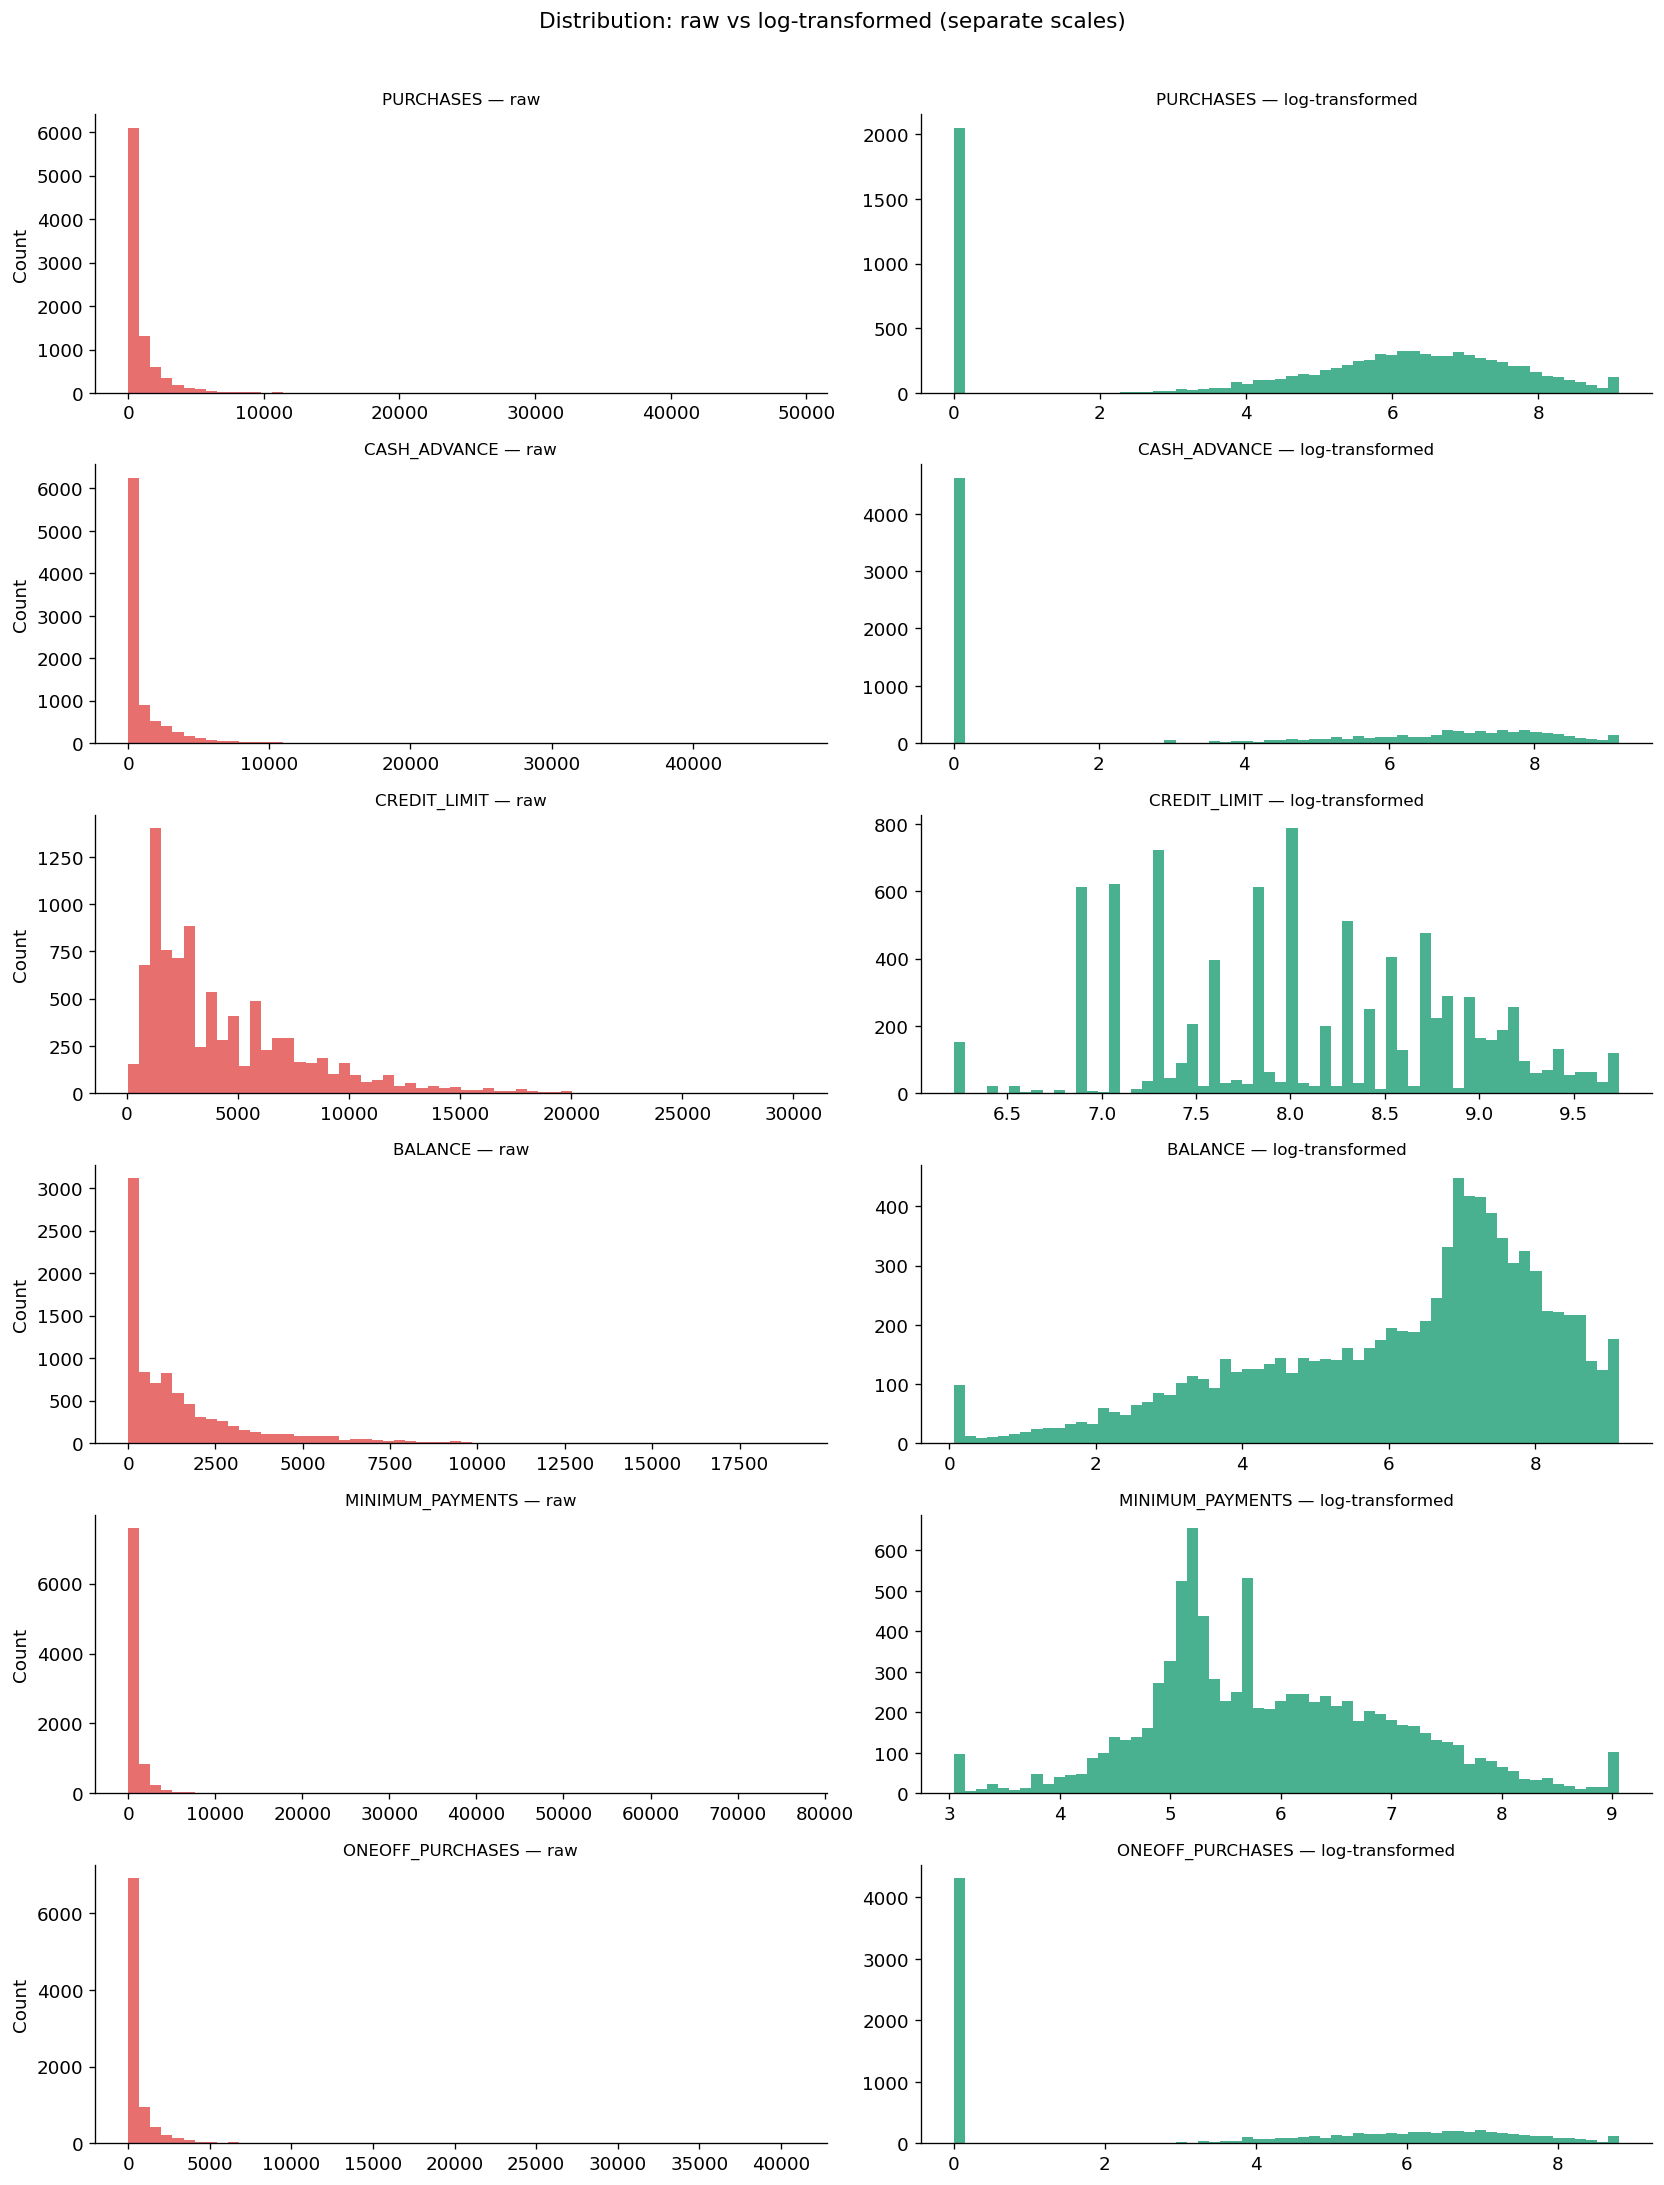

In [16]:
sample_cols = ['PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
               'BALANCE', 'MINIMUM_PAYMENTS', 'ONEOFF_PURCHASES']

fig, axes = plt.subplots(len(sample_cols), 2, figsize=(14, 18))

for i, col in enumerate(sample_cols):
    # Left: raw
    axes[i, 0].hist(df[col], bins=60, color='#E24B4A', alpha=0.8, edgecolor='none')
    axes[i, 0].set_title(f'{col} — raw', fontsize=10)
    axes[i, 0].set_ylabel('Count')

    # Right: log-transformed
    axes[i, 1].hist(df_log[col], bins=60, color='#1D9E75', alpha=0.8, edgecolor='none')
    axes[i, 1].set_title(f'{col} — log-transformed', fontsize=10)

plt.suptitle('Distribution: raw vs log-transformed (separate scales)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig3_distributions_fixed.png', bbox_inches='tight')
plt.show()

In [17]:
# After Block 11, add this analysis block

print("=== Zero-value analysis (important for clustering interpretation) ===")
zero_cols = ['PURCHASES', 'CASH_ADVANCE', 'ONEOFF_PURCHASES', 
             'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX']

for col in zero_cols:
    n_zeros = (df[col] == 0).sum()
    pct = n_zeros / len(df) * 100
    print(f"  {col:<30} zeros: {n_zeros:>4} ({pct:.1f}%)")

=== Zero-value analysis (important for clustering interpretation) ===
  PURCHASES                      zeros: 2044 (22.8%)
  CASH_ADVANCE                   zeros: 4628 (51.7%)
  ONEOFF_PURCHASES               zeros: 4302 (48.1%)
  INSTALLMENTS_PURCHASES         zeros: 3916 (43.8%)
  CASH_ADVANCE_TRX               zeros: 4628 (51.7%)
  PURCHASES_TRX                  zeros: 2044 (22.8%)


PCA scree plot

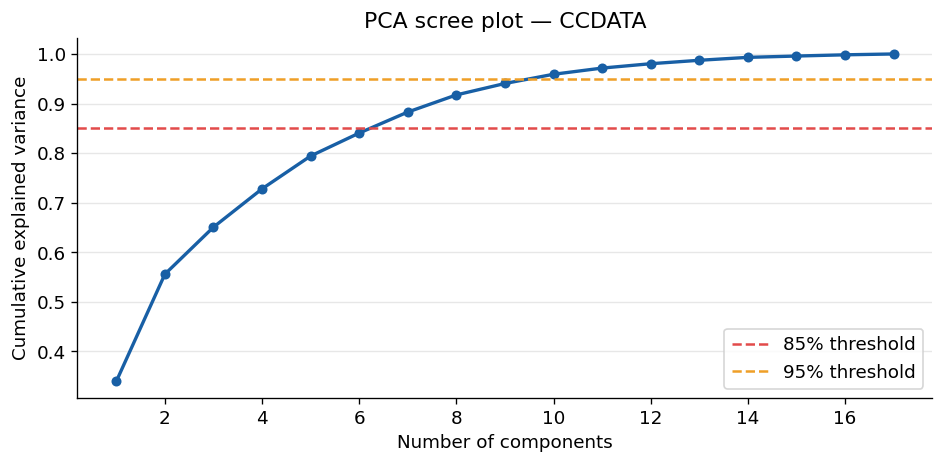

80% variance explained by 6 components
85% variance explained by 7 components
90% variance explained by 8 components
95% variance explained by 10 components


In [13]:
pca_full = PCA()
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar, marker='o',
         color='#185FA5', linewidth=2, markersize=5)
plt.axhline(0.85, color='#E24B4A', linestyle='--', label='85% threshold')
plt.axhline(0.95, color='#EF9F27', linestyle='--', label='95% threshold')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA scree plot — CCDATA')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_pca_scree.png', bbox_inches='tight')
plt.show()

for threshold in [0.80, 0.85, 0.90, 0.95]:
    n = np.argmax(cumvar >= threshold) + 1
    print(f'{int(threshold*100)}% variance explained by {n} components')

PCA 2D projection (for later visualization)

Variance explained by 2 components: 55.6%


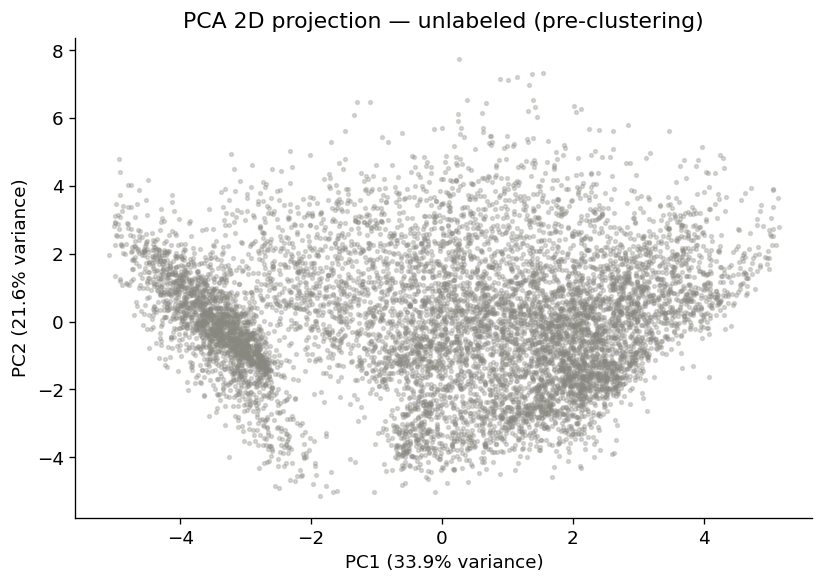

In [14]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

print(f'Variance explained by 2 components: '
      f'{pca_2d.explained_variance_ratio_.sum():.1%}')

# Quick sanity check — plot with no labels yet
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=5, color='#888780')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA 2D projection — unlabeled (pre-clustering)')
plt.tight_layout()
plt.savefig('fig5_pca_2d_unlabeled.png', bbox_inches='tight')
plt.show()

 Save outputs

In [15]:
X_scaled.to_csv('X_scaled.csv', index=False)
np.save('X_pca.npy', X_pca)

import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca_2d, 'pca_2d.pkl')

print('Saved:')
print('  X_scaled.csv  — model input for all 4 clustering algorithms')
print('  X_pca.npy     — 2D projection for cluster visualization')
print('  scaler.pkl    — fitted scaler (needed to inverse-transform for interpretation)')
print('  pca_2d.pkl    — fitted PCA (reuse in Phase 3 for cluster plots)')

Saved:
  X_scaled.csv  — model input for all 4 clustering algorithms
  X_pca.npy     — 2D projection for cluster visualization
  scaler.pkl    — fitted scaler (needed to inverse-transform for interpretation)
  pca_2d.pkl    — fitted PCA (reuse in Phase 3 for cluster plots)
